In [1]:
import sys, math, warnings, time
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from scipy.integrate import solve_ivp

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

# Resolve project root so the project modules import cleanly
project_folder_name = "MFC2024"
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Project imports
from config.settings    import solver_variable_names, solver_flux_names
from config.initialize  import parameters, operating_inputs, init_x_for
from model.dualscale    import PEMFC
from model.kinetic_eq   import Rproton, eta_ccl, fdrop
from model.coefficients import n_cell

I_TARGET = 10.0  # A -- the single current point we calibrate against

In [2]:
# ---- Cell 2: Import experiment data ----
exp_file       = project_root / "data" / "Polar_curves.xlsx"
polardata_exp  = pd.read_excel(exp_file, sheet_name=None)  # dict: cond_key -> DataFrame
print(f"Loaded {len(polardata_exp)} conditions from {exp_file.name}")

Loaded 12 conditions from Polar_curves.xlsx


In [3]:
# ---- Cell 3: Extract experimental VFC at I=10 A for every condition ----
vfc_10A = {}  # cond_key -> (i_actual, ucell_per_cell)
for cond_key, df in polardata_exp.items():
    i_exp = df["I_LOAD"].to_numpy(dtype=float)
    v_exp = df["VFC"].to_numpy(dtype=float) / n_cell  # stack voltage -> per-cell voltage
    idx   = int(np.argmin(np.abs(i_exp - I_TARGET)))  # nearest row to 10 A
    vfc_10A[cond_key] = (float(i_exp[idx]), float(v_exp[idx]))

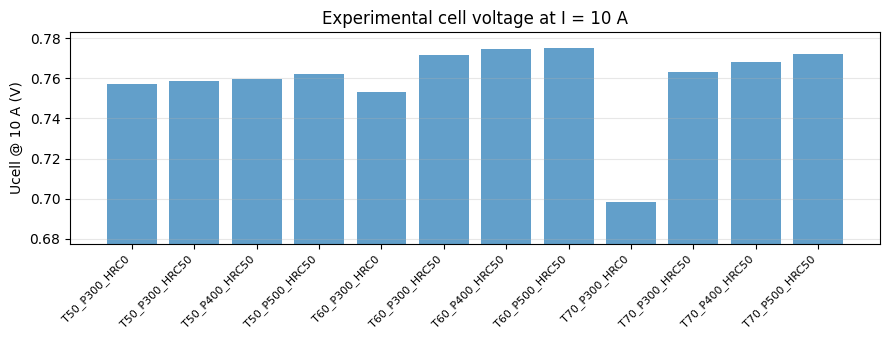

In [4]:
# ---- Cell 4: Bar chart of experimental Ucell @ 10 A ----
cond_keys = list(vfc_10A.keys())
ucell_exp_arr = np.array([vfc_10A[k][1] for k in cond_keys])  # target voltages

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(range(len(cond_keys)), ucell_exp_arr, color="tab:blue", alpha=0.7)
ax.set_xticks(range(len(cond_keys)))
ax.set_xticklabels(cond_keys, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Ucell @ 10 A (V)")
ax.set_title("Experimental cell voltage at I = 10 A")
ax.set_ylim(ucell_exp_arr.min() * 0.97, ucell_exp_arr.max() * 1.01)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# ---- Cell 5: Single-point simulator (robust to failures and NaN) ----
def simulate_point(cond_key, params_override):
    # Decode the condition key (e.g. T60_P400_HRC50 -> 60degC, 4 bar gauge + 1e5, 50% RH)
    T_des = int(cond_key.split("_")[0][1:])
    P_des = int(cond_key.split("_")[1][1:]) * 100 + 1e5
    RHC   = int(cond_key.split("_")[2][3:])

    p  = deepcopy(parameters);  p.update(params_override)  # apply trial parameters
    p["aux_system"] = False  # disable BoP -- we only calibrate stack-level params
    op = deepcopy(operating_inputs)
    op["Tfc"]       = T_des + 273.15
    op["Pa_des"]    = P_des
    op["Pc_des"]    = P_des
    op["Phi_c_des"] = RHC / 100

    i_density = I_TARGET / p["Aact"]  # convert load current to current density
    op["current_density"] = lambda t, _i=i_density: _i

    try:
        model = PEMFC(param=p, operating_inputs=op,
                      variable_names=solver_variable_names,
                      flux_names=solver_flux_names)
        x0  = init_x_for("dual-scale", op, model.parameters)
        sol = solve_ivp(model.dxdt, (0, 30), x0, method="BDF", max_step=2e-1)  # 30 s -> steady state
    except Exception:
        return None    # constructor / initializer / solver itself raised -> skip this point

    if not sol.success:
        return None    # solver flagged failure (step size collapse, divergence, etc.)

    last = {k: sol.y[idx, -1] for idx, k in enumerate(model.variable_names)}
    if not np.all(np.isfinite(list(last.values()))):
        return None    # final state contains NaN/Inf even though solver claimed success

    try:
        Rmem, _, _ = Rproton(last, model.parameters, op)
        eta_c      = eta_ccl(last, op, model.parameters)
    except Exception:
        return None    # kinetic/transport eval blew up on the (possibly extreme) final state

    Rmem_sum = float(np.sum(Rmem))
    if not (np.isfinite(Rmem_sum) and np.isfinite(eta_c)):
        return None    # NaN in Rmem or overpotential -> Ucell would be NaN

    Ucell = p["OCV"] - i_density * (Rmem_sum + p["Re"]) - eta_c  # full cell voltage balance
    if not (np.isfinite(Ucell) and 0.0 < Ucell < 1.3):
        return None    # unphysical voltage -> reject so Optuna penalises it as a fail
    return float(Ucell)

Simulating all conditions with warm-start parameters ...
Done in 42.2 s.   Failed/NaN: 0/12


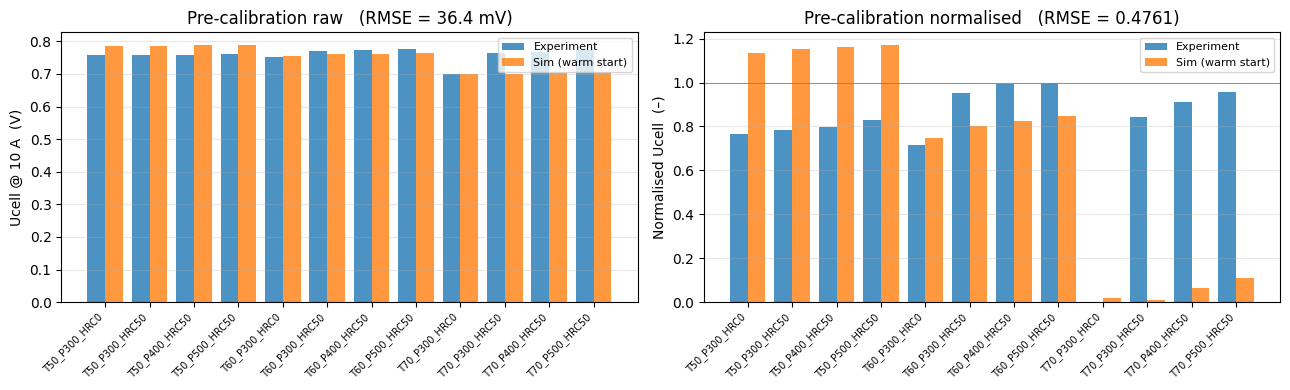


Condition             Exp (V)    Sim (V)    dV (mV)
--------------------------------------------------
T50_P300_HRC0          0.7572     0.7853       28.1
T50_P300_HRC50         0.7585     0.7868       28.3
T50_P400_HRC50         0.7595     0.7875       28.0
T50_P500_HRC50         0.7622     0.7881       25.9
T60_P300_HRC0          0.7533     0.7558        2.4
T60_P300_HRC50         0.7715     0.7599      -11.6
T60_P400_HRC50         0.7748     0.7618      -12.9
T60_P500_HRC50         0.7751     0.7636      -11.5
T70_P300_HRC0          0.6986     0.7000        1.4
T70_P300_HRC50         0.7630     0.6994      -63.6
T70_P400_HRC50         0.7682     0.7034      -64.9
T70_P500_HRC50         0.7719     0.7071      -64.7


In [6]:
# ---- Cell 6: Sanity-check simulation with the warm-start (manual) parameters ----
COND_KEYS = list(vfc_10A.keys())
U_EXP     = np.array([vfc_10A[k][1] for k in COND_KEYS])  # raw target Ucell vector (V)

# Min-max normalization constants from experiment -- applied identically to sim so the two stay comparable
U_MIN, U_MAX = float(U_EXP.min()), float(U_EXP.max())
U_SPAN       = U_MAX - U_MIN                              # voltage spread across conditions (~0.08 V)
U_EXP_NORM   = (U_EXP - U_MIN) / U_SPAN                   # exp targets mapped to [0, 1]

# Warm-start parameters carried over from manual_polar.ipynb -- reused as Optuna's first trial
warm_start_params = {
    "OCV": 0.84, "i0_c_ref": 1.1556, "kappa_c": 2.624, "tau": 1.554,
    "Re": 9.521e-06, "epsilon_mc": 0.1836, "epsilon_gdl": 0.6,
    "epsilon_c": 0.223, "epsilon_cl": 0.1588, "a_slim": 0.02,
    "b_slim": 0.25, "a_switch": 0.1, "Hcl": 1.47e-5, "Hgdl": 2.85e-4,
}

# Run the model once at every condition with warm_start_params
print("Simulating all conditions with warm-start parameters ...")
t0 = time.perf_counter()
u_sim_raw  = [simulate_point(k, warm_start_params) for k in COND_KEYS]            # list of float or None
u_sim_init = np.array([np.nan if u is None else u for u in u_sim_raw], dtype=float)  # None -> NaN
t_elapsed  = time.perf_counter() - t0
n_fail     = int(np.sum(~np.isfinite(u_sim_init)))
print(f"Done in {t_elapsed:.1f} s.   Failed/NaN: {n_fail}/{len(COND_KEYS)}")

# Pre-calibration error metrics
u_sim_init_n   = (u_sim_init - U_MIN) / U_SPAN                                   # normalised sim
rmse_init_raw  = float(np.sqrt(np.nanmean((u_sim_init   - U_EXP)      ** 2)))    # V
rmse_init_norm = float(np.sqrt(np.nanmean((u_sim_init_n - U_EXP_NORM) ** 2)))    # dimensionless

# Side-by-side bars (raw + normalised)
x = np.arange(len(COND_KEYS))
fig, (ax_r, ax_n) = plt.subplots(1, 2, figsize=(13, 4))

ax_r.bar(x - 0.2, U_EXP,      width=0.4, color="tab:blue",   alpha=0.8, label="Experiment")
ax_r.bar(x + 0.2, u_sim_init, width=0.4, color="tab:orange", alpha=0.8, label="Sim (warm start)")
ax_r.set_xticks(x); ax_r.set_xticklabels(COND_KEYS, rotation=45, ha="right", fontsize=7)
ax_r.set_ylabel("Ucell @ 10 A  (V)")
ax_r.set_title(f"Pre-calibration raw   (RMSE = {rmse_init_raw*1000:.1f} mV)")
ax_r.grid(True, axis="y", alpha=0.3); ax_r.legend(fontsize=8)

ax_n.bar(x - 0.2, U_EXP_NORM,   width=0.4, color="tab:blue",   alpha=0.8, label="Experiment")
ax_n.bar(x + 0.2, u_sim_init_n, width=0.4, color="tab:orange", alpha=0.8, label="Sim (warm start)")
ax_n.set_xticks(x); ax_n.set_xticklabels(COND_KEYS, rotation=45, ha="right", fontsize=7)
ax_n.set_ylabel("Normalised Ucell  (–)")
ax_n.set_title(f"Pre-calibration normalised   (RMSE = {rmse_init_norm:.4f})")
ax_n.axhline(0, color="grey", linewidth=0.6); ax_n.axhline(1, color="grey", linewidth=0.6)
ax_n.grid(True, axis="y", alpha=0.3); ax_n.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Per-condition delta -- a uniform offset suggests OCV/Re; condition-dependent gap suggests kinetics / mass transport
print(f"\n{'Condition':18s}  {'Exp (V)':>9s}  {'Sim (V)':>9s}  {'dV (mV)':>9s}")
print("-" * 50)
for k, ue, us in zip(COND_KEYS, U_EXP, u_sim_init):
    dv     = (us - ue) * 1000 if np.isfinite(us) else float("nan")
    us_str = f"{us:9.4f}" if np.isfinite(us) else "     fail"
    dv_str = f"{dv:9.1f}" if np.isfinite(dv) else "      nan"
    print(f"{k:18s}  {ue:9.4f}  {us_str}  {dv_str}")

In [7]:
# ---- Cell 7: Optuna objective using normalised SSE over all conditions @ 10 A ----
# Uses COND_KEYS, U_EXP_NORM, U_MIN, U_SPAN defined in the sanity-check cell above.
def objective(trial):
    params_trial = {
        "OCV":         trial.suggest_float("OCV",         0.80,  1.00),
        "i0_c_ref":    trial.suggest_float("i0_c_ref",    0.01,  15.0,  log=True),
        "kappa_c":     trial.suggest_float("kappa_c",     0.5,   3.0),
        # "tau":         trial.suggest_float("tau",         1.0,   4.0),
        # "Re":          trial.suggest_float("Re",          5e-7,  1e-5,  log=True),
        "epsilon_mc":  trial.suggest_float("epsilon_mc",  0.15,  0.5),
        #"epsilon_gdl": trial.suggest_float("epsilon_gdl", 0.5,   0.8),
        "epsilon_c":   trial.suggest_float("epsilon_c",   0.05,  0.35),
        "epsilon_cl":  trial.suggest_float("epsilon_cl",  0.1,   0.5),
        # "a_slim":      trial.suggest_float("a_slim",      5e-3,  0.3,   log=True),
        # "b_slim":      trial.suggest_float("b_slim",      0.1,   0.9),
        # "a_switch":    trial.suggest_float("a_switch",    0.05,  0.5),
        "Hcl":         trial.suggest_float("Hcl",         1e-5,  3e-5,  log=True),
        "Hgdl":        trial.suggest_float("Hgdl",        1e-4,  4e-4,  log=True),
    }

    sse, n_fail = 0.0, 0
    for cond_key, u_target_norm in zip(COND_KEYS, U_EXP_NORM):
        u_sim = simulate_point(cond_key, params_trial)
        if u_sim is None:
            n_fail += 1
            continue
        u_sim_norm = (u_sim - U_MIN) / U_SPAN          # same transform applied to sim -> dimensionless
        sse += (u_sim_norm - u_target_norm) ** 2       # squared error in normalised units
    sse += n_fail * 1.0  # penalty per failed condition -- matches magnitude of a fully off normalised error
    return sse

In [8]:
# ---- Cell 8: Run Optuna study ----
N_TRIALS = 100          # number of parameter sets to try
TIMEOUT  = 60 * 10     # 10 min wall-clock cap

study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=42))

study.enqueue_trial(warm_start_params)   # reuse the same manual values shown in the sanity check

study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT, show_progress_bar=True)

best_params = study.best_params
print(f"\nCompleted {len(study.trials)} trials.   Best SSE = {study.best_value:.6f}")
print(f"{'Parameter':15s}  {'Best fit':>12s}")
print("-" * 30)
for k, v in best_params.items():
    print(f"  {k:13s}  {v:12.4g}")

  0%|          | 0/100 [00:00<?, ?it/s]


Completed 16 trials.   Best SSE = 1.176041
Parameter            Best fit
------------------------------
  OCV                   0.803
  i0_c_ref               13.9
  kappa_c               2.482
  epsilon_mc             0.27
  epsilon_c            0.2827
  epsilon_cl            0.364
  Hcl               1.918e-05
  Hgdl              0.0001946


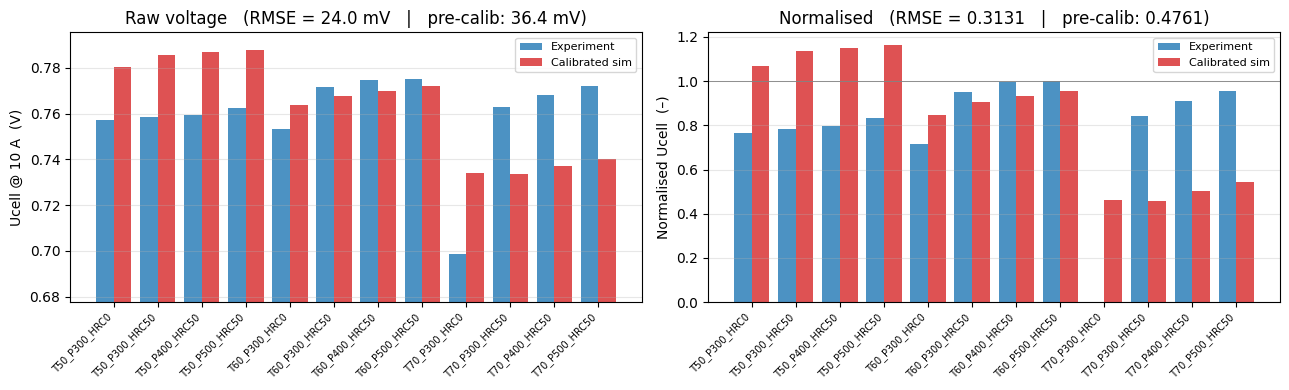


Failed/NaN conditions: 0/12

Condition             Exp (V)    Sim (V)    dV (mV)    Exp_n    Sim_n
----------------------------------------------------------------------
T50_P300_HRC0          0.7572     0.7803       23.0    0.766    1.067
T50_P300_HRC50         0.7585     0.7857       27.2    0.783    1.139
T50_P400_HRC50         0.7595     0.7867       27.2    0.796    1.151
T50_P500_HRC50         0.7622     0.7876       25.3    0.832    1.163
T60_P300_HRC0          0.7533     0.7635       10.2    0.715    0.849
T60_P300_HRC50         0.7715     0.7679       -3.7    0.953    0.905
T60_P400_HRC50         0.7748     0.7699       -4.8    0.996    0.932
T60_P500_HRC50         0.7751     0.7719       -3.3    1.000    0.957
T70_P300_HRC0          0.6986     0.7340       35.4    0.000    0.462
T70_P300_HRC50         0.7630     0.7336      -29.4    0.841    0.457
T70_P400_HRC50         0.7682     0.7371      -31.2    0.910    0.503
T70_P500_HRC50         0.7719     0.7404      -31.5    0.95

In [9]:
# ---- Cell 9: Re-simulate every condition with best_params and plot (raw + normalised) ----
u_sim_list = [simulate_point(k, best_params) for k in COND_KEYS]                 # call once per condition
u_sim_arr  = np.array([u if u is not None else np.nan for u in u_sim_list])      # None -> NaN for plotting

# Apply the SAME normalization used during optimisation
u_sim_norm = (u_sim_arr - U_MIN) / U_SPAN     # dimensionless sim values

rmse_raw  = float(np.sqrt(np.nanmean((u_sim_arr  - U_EXP)      ** 2)))           # V
rmse_norm = float(np.sqrt(np.nanmean((u_sim_norm - U_EXP_NORM) ** 2)))           # dimensionless

x = np.arange(len(COND_KEYS))
fig, (ax_raw, ax_norm) = plt.subplots(1, 2, figsize=(13, 4))

# --- Raw V bar chart ---
ax_raw.bar(x - 0.2, U_EXP,     width=0.4, color="tab:blue", alpha=0.8, label="Experiment")
ax_raw.bar(x + 0.2, u_sim_arr, width=0.4, color="tab:red",  alpha=0.8, label="Calibrated sim")
ax_raw.set_xticks(x); ax_raw.set_xticklabels(COND_KEYS, rotation=45, ha="right", fontsize=7)
ax_raw.set_ylabel("Ucell @ 10 A  (V)")
ax_raw.set_title(f"Raw voltage   (RMSE = {rmse_raw*1000:.1f} mV   |   pre-calib: {rmse_init_raw*1000:.1f} mV)")
ax_raw.set_ylim(min(U_EXP.min(), np.nanmin(u_sim_arr)) * 0.97,
                max(U_EXP.max(), np.nanmax(u_sim_arr)) * 1.01)
ax_raw.grid(True, axis="y", alpha=0.3); ax_raw.legend(fontsize=8)

# --- Normalised bar chart (what the optimizer actually saw) ---
ax_norm.bar(x - 0.2, U_EXP_NORM, width=0.4, color="tab:blue", alpha=0.8, label="Experiment")
ax_norm.bar(x + 0.2, u_sim_norm, width=0.4, color="tab:red",  alpha=0.8, label="Calibrated sim")
ax_norm.set_xticks(x); ax_norm.set_xticklabels(COND_KEYS, rotation=45, ha="right", fontsize=7)
ax_norm.set_ylabel("Normalised Ucell  (–)")
ax_norm.set_title(f"Normalised   (RMSE = {rmse_norm:.4f}   |   pre-calib: {rmse_init_norm:.4f})")
ax_norm.axhline(0, color="grey", linewidth=0.6); ax_norm.axhline(1, color="grey", linewidth=0.6)
ax_norm.grid(True, axis="y", alpha=0.3); ax_norm.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Per-condition table
n_fail = sum(u is None for u in u_sim_list)
print(f"\nFailed/NaN conditions: {n_fail}/{len(COND_KEYS)}")
print(f"\n{'Condition':18s}  {'Exp (V)':>9s}  {'Sim (V)':>9s}  {'dV (mV)':>9s}  {'Exp_n':>7s}  {'Sim_n':>7s}")
print("-" * 70)
for k, ue, us, uen, usn in zip(COND_KEYS, U_EXP, u_sim_arr, U_EXP_NORM, u_sim_norm):
    dv      = (us - ue) * 1000 if np.isfinite(us) else float("nan")
    us_str  = f"{us:9.4f}" if np.isfinite(us) else "     fail"
    usn_str = f"{usn:7.3f}" if np.isfinite(usn) else "   fail"
    dv_str  = f"{dv:9.1f}" if np.isfinite(dv) else "      nan"
    print(f"{k:18s}  {ue:9.4f}  {us_str}  {dv_str}  {uen:7.3f}  {usn_str}")

Done in 24.2 s


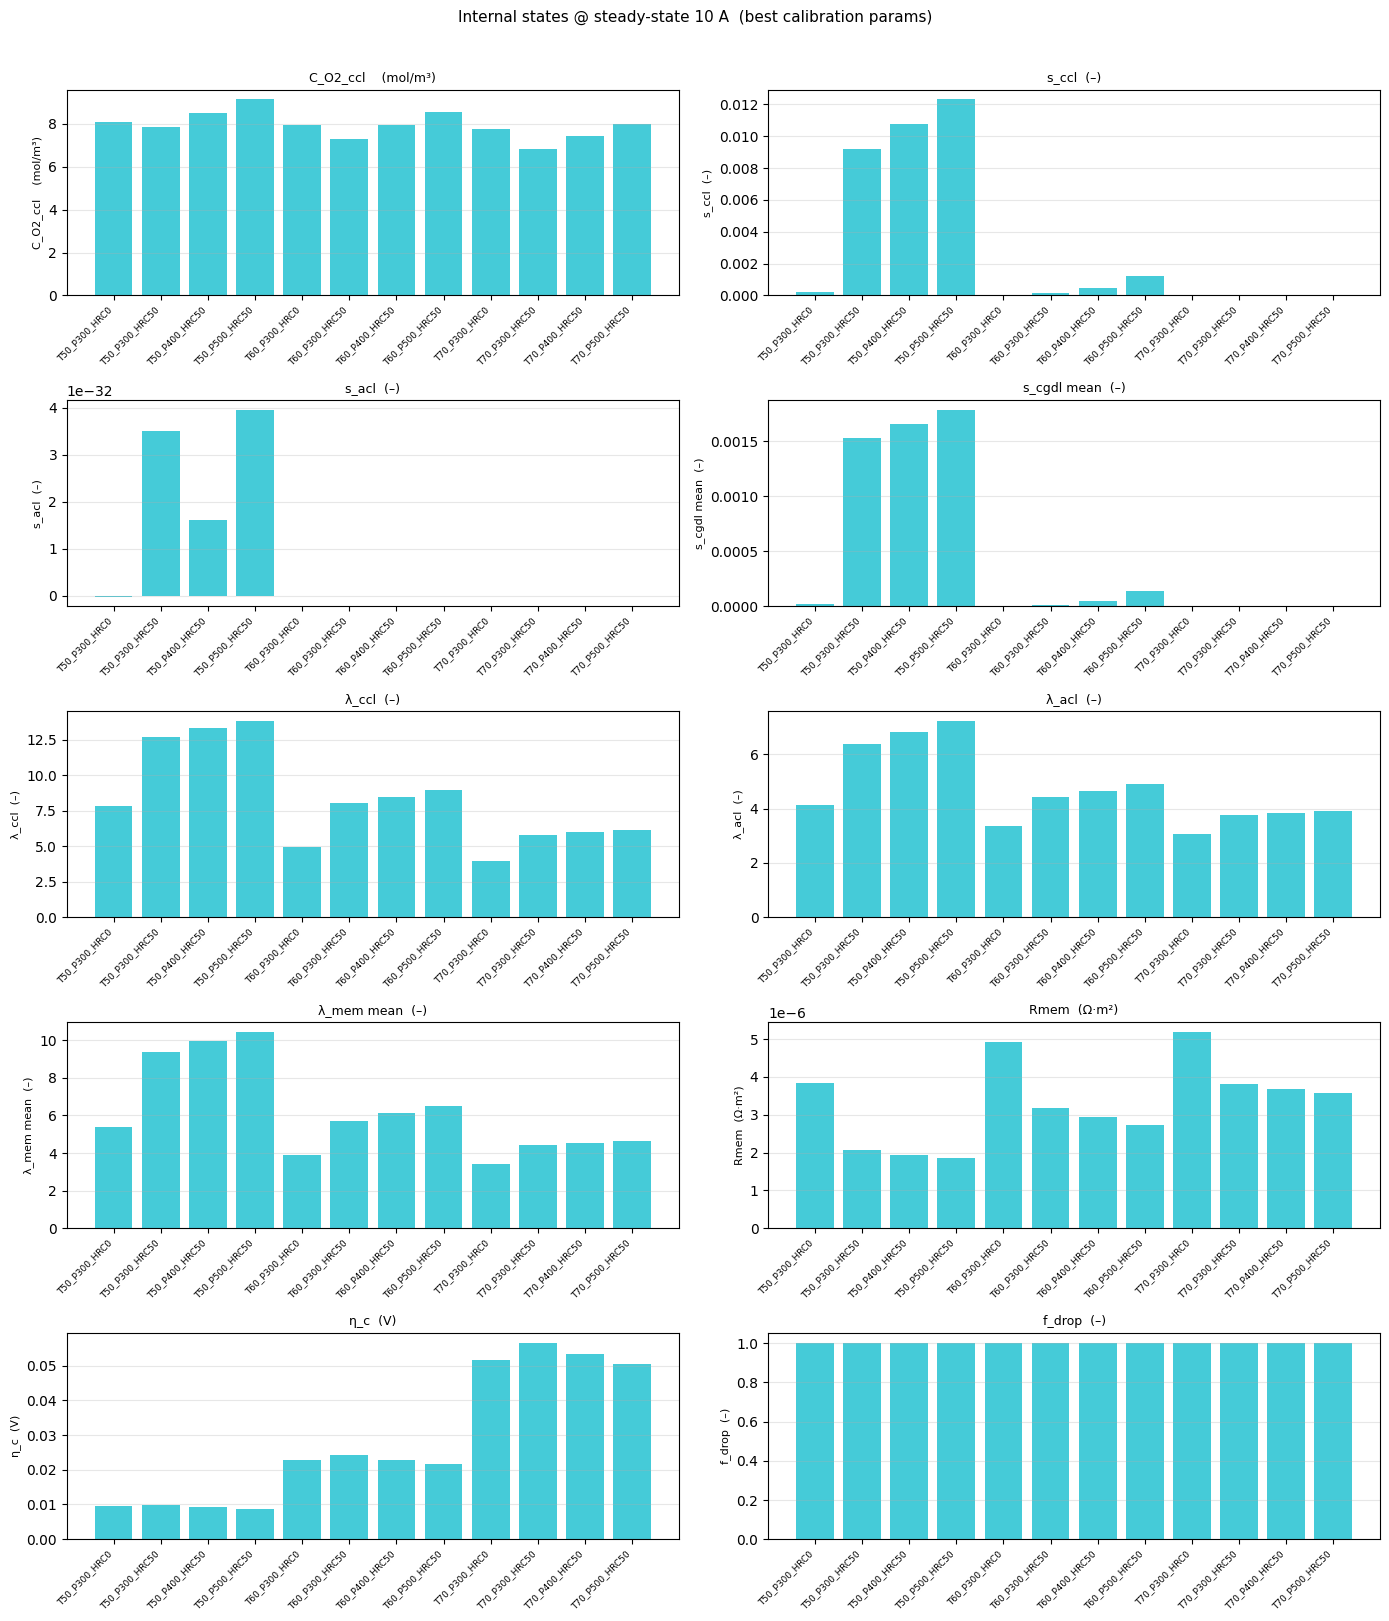

In [12]:
# ---- Cell 10: Internal state comparison across conditions (best_params) ----
from model.kinetic_eq import Rproton, eta_ccl, fdrop

def simulate_point_states(cond_key, params_override):
    """Like simulate_point but returns a dict of final internal states + derived quantities."""
    T_des = int(cond_key.split("_")[0][1:])
    P_des = int(cond_key.split("_")[1][1:]) * 100 + 1e5
    RHC   = int(cond_key.split("_")[2][3:])

    p  = deepcopy(parameters);  p.update(params_override)
    p["aux_system"] = False
    op = deepcopy(operating_inputs)
    op["Tfc"]       = T_des + 273.15
    op["Pa_des"]    = P_des
    op["Pc_des"]    = P_des
    op["Phi_c_des"] = RHC / 100

    i_density = I_TARGET / p["Aact"]
    op["current_density"] = lambda t, _i=i_density: _i

    try:
        model = PEMFC(param=p, operating_inputs=op,
                      variable_names=solver_variable_names,
                      flux_names=solver_flux_names)
        x0  = init_x_for("dual-scale", op, model.parameters)
        sol = solve_ivp(model.dxdt, (0, 30), x0, method="BDF", max_step=2e-1)
    except Exception:
        return None

    if not sol.success:
        return None

    last = {k: sol.y[idx, -1] for idx, k in enumerate(model.variable_names)}
    if not np.all(np.isfinite(list(last.values()))):
        return None

    n_mem = p["n_mem"]
    n_gdl = p["n_gdl"]

    try:
        Rmem_arr, _, _ = Rproton(last, model.parameters, op)
        eta_c_val      = eta_ccl(last, op, model.parameters)
        fdrop_val      = fdrop(last, op, model.parameters)
    except Exception:
        return None

    return {
        "C_O2_ccl":    last["C_O2_ccl"],
        "s_ccl":       last["s_ccl"],
        "s_acl":       last["s_acl"],
        "lambda_ccl":  last["lambda_ccl"],
        "lambda_acl":  last["lambda_acl"],
        "lambda_mem":  float(np.mean([last[f"lambda_mem_{i}"] for i in range(1, n_mem + 1)])),
        "s_cgdl_mean": float(np.mean([last[f"s_cgdl_{i}"] for i in range(1, n_gdl + 1)])),
        "Rmem":        float(np.sum(Rmem_arr)),
        "eta_c":       float(eta_c_val),
        "fdrop":       float(fdrop_val),
    }

print("Collecting internal states for all conditions ...")
t0 = time.perf_counter()
states_list = [simulate_point_states(k, best_params) for k in COND_KEYS]
print(f"Done in {time.perf_counter() - t0:.1f} s")

# ---- Build per-variable arrays (NaN where simulation failed) ----
STATE_VARS = {
    "C_O2_ccl    (mol/m³)": "C_O2_ccl",
    "s_ccl  (–)":           "s_ccl",
    "s_acl  (–)":           "s_acl",
    "s_cgdl mean  (–)":     "s_cgdl_mean",
    "λ_ccl  (–)":           "lambda_ccl",
    "λ_acl  (–)":           "lambda_acl",
    "λ_mem mean  (–)":      "lambda_mem",
    "Rmem  (Ω·m²)":         "Rmem",
    "η_c  (V)":             "eta_c",
    "f_drop  (–)":          "fdrop",
}

data = {}
for label, key in STATE_VARS.items():
    data[label] = np.array([
        s[key] if s is not None else np.nan for s in states_list
    ])

# ---- Plot grid ----
n_vars = len(STATE_VARS)
n_cols = 2
n_rows = math.ceil(n_vars / n_cols)
x = np.arange(len(COND_KEYS))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.2))
axes = axes.flatten()

for ax, (label, arr) in zip(axes, data.items()):
    ax.bar(x, arr, color="tab:cyan", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(COND_KEYS, rotation=45, ha="right", fontsize=6.5)
    ax.set_ylabel(label, fontsize=8)
    ax.set_title(label, fontsize=9)
    ax.grid(True, axis="y", alpha=0.3)

# hide any unused subplots
for ax in axes[n_vars:]:
    ax.set_visible(False)

fig.suptitle("Internal states @ steady-state 10 A  (best calibration params)", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()
